# Imports, dataset upload

In [1]:
!pip install rapidfuzz
!pip install catboost
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer
import textwrap
from typing import Literal
import re
import json
from urllib.parse import urlparse
from requests import Session
import warnings
from rapidfuzz import process, fuzz
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from catboost import CatBoostRegressor, Pool

pd.set_option('display.max_colwidth', None)
plt.style.use('ggplot')
%matplotlib inline

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


In [21]:
df = pd.read_excel('data.xlsx').rename(columns = {'Потенциал':'Potential'})
df.head()

,Customer,Volume,Office,Trade_Channel,Territory,Cust_Hier,Price_Group,Customer_Classific,CDE_Doors,Visit_Frequency,Potential
0,3846731262,21.130,Volgograd/Saratov,Kiosk/Food,380302,38613101,32,SF,0,2,IR
1,3802000331,2022.454,Vladivstk/Prim/Nakhd,Small trad food stor,380605,38516205,14,SF,2.7,1,PL
2,3899990872,38.723,Barnaul,Other Local & Tradit,380603,38616101,14,WE,2.7,1,GO
3,3835027155,116.225,Simferopol,Butcher Shop,380304,38613110,12,SF,1,1,SI
4,3867706099,69.084,Novosibirsk,Break Corner,380603,38526101,32,TE,0.5,2,SI


# EDA

## Dataset overview

**Target variable** - 'Volume'

**Features classification**:
* Numerical - 'CDE_Doors', 'Visit_Frequency'
* Categorical:
  * Nominal - 'Customer', 'Office', 'Trade_Channel', 'Territory', 'Customer_Classific'
  * Ordinal - 'Cust_Hier', 'Price_Group', 'Potential'

In [22]:
target = 'Volume'
cat_features = ['Customer','Office','Trade_Channel','Territory','Price_Group','Customer_Classific','Cust_Hier','Potential']
num_features = ['CDE_Doors', 'Visit_Frequency']

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Customer            100000 non-null  int64  
 1   Volume              100000 non-null  float64
 2   Office              100000 non-null  object 
 3   Trade_Channel       100000 non-null  object 
 4   Territory           100000 non-null  int64  
 5   Cust_Hier           100000 non-null  int64  
 6   Price_Group         100000 non-null  int64  
 7   Customer_Classific  100000 non-null  object 
 8   CDE_Doors           100000 non-null  object 
 9   Visit_Frequency     100000 non-null  object 
 10  Potential           100000 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 8.4+ MB


**Observations**:
1. No explicit missing values.
2. Categorical features dominate the dataset (7/9).
3. Below features are mistyped:
    * Customer: int -> category
    * Territory: int -> category
    * Cust_Hier: int -> category
    * Price_Group: int -> category
    * CDE_Doors: object -> float
    * Visit_Frequency: object -> float

## Data preprocessing

### Degenerate feature elimination

In [24]:
(df['Customer'].value_counts() == 1).all()

np.True_

In [25]:
df = df.drop(columns = 'Customer')
cat_features.remove('Customer')

### Dtypes correction

In [26]:
def is_convertible(from_type: str, to_type: Literal['int', 'str', 'float', 'bool']):
    try:
        to_type(from_type)
        return True
    except:
           return False

In [27]:
# casting categorical features to str
for feat in cat_features:
    try:
        df[feat] = df[feat].astype(str)
    except:
           mask = df[feat].apply(lambda x: not is_convertible(x, str))
           not_convertible = df[mask][feat].unique()
           print(f"'{feat}' values uncastable to str: {not_convertible}/n")

In [28]:
# casting numerical features to float
for feat in num_features:
    try:
        df[feat] = df[feat].astype(float)
    except:
           mask = df[feat].apply(lambda x: not is_convertible(x, float))
           not_convertible = df[mask][feat].unique()
           print(f"'{feat}' values uncastable to float:\n{', '.join(not_convertible)}\n")

'CDE_Doors' values uncastable to float:
2,7, #, 0,7, 0,5, 1,5, 0,3, 0,0, 1,0, 2,0, 2,5, 6,0, 4,0, 1,7, 1,4, 3,0

'Visit_Frequency' values uncastable to float:
Not assigned, 2,5



In [29]:
# standardizing decimal notation
for feat in num_features:
    df[feat] = df[feat].apply(lambda x: x.replace(',','.') if isinstance(x, str) else x)

In [30]:
print("Cross-feature Jaccard similarity between 'Not assigned' and '0' values of 'Visit_Frequency':")
for feat in ['Cust_Hier','Trade_Channel']:
    na_cats, zero_cats = set(df[df['Visit_Frequency'] == 'Not assigned'][feat]), set(df[df['Visit_Frequency'] == '0'][feat])
    print(f"{feat}: {len(na_cats & zero_cats) / len(na_cats | zero_cats) * 100:.2f}%")

Cross-feature Jaccard similarity between 'Not assigned' and '0' values of 'Visit_Frequency':
Cust_Hier: 36.27%
Trade_Channel: 56.52%


'Not assigned' and zero values of 'Visit_Frequency' are dissimilar both meaninfully and empirically (insignificant cross-feature Jaccard proximity), which warrants replacing 'Not assigned' values with the feature median:

In [31]:
df['Visit_Frequency'] = df['Visit_Frequency'].replace({'Not assigned': pd.to_numeric(df['Visit_Frequency'], errors = 'coerce').median()}).astype(float)

'#' entries in 'CDE_Doors' are uninterpretable, which also justifies median imputation:

In [32]:
df['CDE_Doors'] = df['CDE_Doors'].replace({'#': pd.to_numeric(df['CDE_Doors'], errors = 'coerce').median()}).astype(float)

In [33]:
# OK
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Volume              100000 non-null  float64
 1   Office              100000 non-null  object 
 2   Trade_Channel       100000 non-null  object 
 3   Territory           100000 non-null  object 
 4   Cust_Hier           100000 non-null  object 
 5   Price_Group         100000 non-null  object 
 6   Customer_Classific  100000 non-null  object 
 7   CDE_Doors           100000 non-null  float64
 8   Visit_Frequency     100000 non-null  float64
 9   Potential           100000 non-null  object 
dtypes: float64(3), object(7)
memory usage: 7.6+ MB


### Improving feature interpretability

'Customer_Classific' categories are shorthand for FMCG customer types. We expand them for clarity:

In [34]:
df['Customer_Classific'] = df['Customer_Classific'].map({'SF':'Supermarket',
                                                         'WE':'Wholesale',
                                                         'ED':'E-com & Digital',
                                                         'FA':'Foodservice & HoReCa',
                                                         'TE':'Traditional',
                                                         'PH':'Pharmacy',
                                                         'PA':'Petrol'})

The 'Territory' and 'Office' features are hierarchically related; therefore, we rename the 'Territory' categories based on the grouping:

In [35]:
df.groupby('Territory')['Office'].unique()

,Office
Territory,
380101,"[MRD West, City West, MRD East, City East, MRD Execution, Transportations-Sado, Moscow Execution, E-com, Moscow Technical, McDonalds, WHS FC]"
380201,"[SPB Execution, SPB City, Kalin/Mnsk/Arkh/Ptrz, LenObl/Novg/Psk, Tver/Vologd/Smolensk, NORTH-WEST Technical, SPB WHS]"
380302,"[Volgograd/Saratov, GRP/Astrakhan/Elista, Rostov city/rural, Rostov reg/LNR/DNR, Dagestan, Voronezh, Chechnya/Ingushetiya, South Technical, South Execution]"
380304,"[Simferopol, Sevastopol, Krasnodar, Novoros/Anapa/Tuapse, Stavropol, Sochi/Adler/Abhaziya, SEACOAST Technical, Seacoast Execution]"
380401,"[Ivan/Vlad/Yrsl/Kstrm, Kursk/Belgorod, Orl/Brnsk/Tula/Klg, NNovgorod/Saransk, Tamb/Lip/Pen/Ryazan, Center W Execution, CENTER W Technical]"
380403,"[Perm/Kirov/Komi, Sam/Tol/Syz-Kuz/Uliy, Kaz/Chel/Al/Cheb/Yos, Ufa/Izhevsk/Birsk, Strl/Ors/Orn/Buz/Bug, CENTER E Technical, Center E Execution]"
380501,"[Chelyabinsk/Magnit, Nizhnevart/Surgut, Ekaterinburg/N.Tagil, Tyumen/Kurgan, Omsk, Urals Execution, URAL Technical, CENTER E Technical]"
380603,"[Barnaul, Novosibirsk, Abakan/Achinsk/Kansk, Irkutsk/Bratsk, Kmrv-Tmsk-Kuz, Krasnoyarsk/Norilsk, SIBERIA Technical, Siberia Execution]"
380605,"[Vladivstk/Prim/Nakhd, Blagoveschensk-Yakut, Chita/Ulan-Ude, Khabarovsk, Sakhalin/Kamchatka, Far East Technical, FAR EAST Execution]"


In [36]:
df['Territory'] = df['Territory'].map({'380101':'Moscow/Moscow Oblast',
                                       '380201':'North-West',
                                       '380302':'South',
                                       '380304':'Seacoast',
                                       '380401':'Center W',
                                       '380403':'Center E',
                                       '380501':'Ural',
                                       '380603':'Siberia',
                                       '380605':'Far East'})

### Removing aggregate 'Office' categories

In [37]:
df.groupby('Territory')['Office'].unique()

,Office
Territory,
Center E,"[Perm/Kirov/Komi, Sam/Tol/Syz-Kuz/Uliy, Kaz/Chel/Al/Cheb/Yos, Ufa/Izhevsk/Birsk, Strl/Ors/Orn/Buz/Bug, CENTER E Technical, Center E Execution]"
Center W,"[Ivan/Vlad/Yrsl/Kstrm, Kursk/Belgorod, Orl/Brnsk/Tula/Klg, NNovgorod/Saransk, Tamb/Lip/Pen/Ryazan, Center W Execution, CENTER W Technical]"
Far East,"[Vladivstk/Prim/Nakhd, Blagoveschensk-Yakut, Chita/Ulan-Ude, Khabarovsk, Sakhalin/Kamchatka, Far East Technical, FAR EAST Execution]"
Moscow/Moscow Oblast,"[MRD West, City West, MRD East, City East, MRD Execution, Transportations-Sado, Moscow Execution, E-com, Moscow Technical, McDonalds, WHS FC]"
North-West,"[SPB Execution, SPB City, Kalin/Mnsk/Arkh/Ptrz, LenObl/Novg/Psk, Tver/Vologd/Smolensk, NORTH-WEST Technical, SPB WHS]"
Seacoast,"[Simferopol, Sevastopol, Krasnodar, Novoros/Anapa/Tuapse, Stavropol, Sochi/Adler/Abhaziya, SEACOAST Technical, Seacoast Execution]"
Siberia,"[Barnaul, Novosibirsk, Abakan/Achinsk/Kansk, Irkutsk/Bratsk, Kmrv-Tmsk-Kuz, Krasnoyarsk/Norilsk, SIBERIA Technical, Siberia Execution]"
South,"[Volgograd/Saratov, GRP/Astrakhan/Elista, Rostov city/rural, Rostov reg/LNR/DNR, Dagestan, Voronezh, Chechnya/Ingushetiya, South Technical, South Execution]"
Ural,"[Chelyabinsk/Magnit, Nizhnevart/Surgut, Ekaterinburg/N.Tagil, Tyumen/Kurgan, Omsk, Urals Execution, URAL Technical, CENTER E Technical]"


In [38]:
df.groupby('Office')[target].describe().sort_values(by = 'mean', ascending = False).head(25)

,count,mean,std,min,25%,50%,75%,max
Office,,,,,,,,
McDonalds,9.0,356026.228778,292730.179194,-1.056000e+00,99923.52500,377839.5980,489998.85700,882706.635
SEACOAST Technical,47.0,137774.975340,661836.909444,1.902000e+00,16.56100,91.1930,2348.32050,4390902.511
Moscow Technical,128.0,71365.970852,291708.787301,-1.665335e-15,75.61750,133.3255,5559.62025,2586915.297
Seacoast Execution,5.0,38900.064600,37894.275409,4.245091e+03,19247.96000,26393.0080,42572.96600,102041.298
South Execution,31.0,38888.562968,72910.256267,2.997300e+01,1439.43700,12661.2910,33418.27800,320390.720
CENTER E Technical,381.0,29369.272346,277579.272758,-2.113000e+00,106.95800,803.3440,1691.58500,4123332.216
South Technical,238.0,27239.982954,362475.949802,5.579000e+00,51.34675,96.9865,211.31325,5569654.549
SPB WHS,1.0,21140.555000,NaN,2.114056e+04,21140.55500,21140.5550,21140.55500,21140.555
NORTH-WEST Technical,106.0,18965.487387,63862.275056,1.690900e+01,316.36275,1467.3505,3325.86400,391961.463


'Technical' and 'Execution' are service categories within 'Office' that aggregate sales at the macro-region or region level. Since they are of no use for forecasting sales to <ins>end customers</ins>, we remove these observations from the dataset:

In [39]:
df = df[~df['Office'].str.lower().str.contains('tech|exec')]

### Target transformation

In [40]:
def plot_hist_per_var(var_list: pd.DataFrame | pd.Series | list[pd.Series]):
    if isinstance(var_list, pd.DataFrame):
       series_list = [var_list.iloc[:, i] for i in range(var_list.shape[1])]
    elif isinstance(var_list, pd.Series):
         series_list = [var_list]
    elif isinstance(var_list, list):
         if all([isinstance(var, pd.Series) for var in var_list]):
            series_list = var_list
         else:
              raise TypeError("All list elements must be of pd.Series type")
    else:
         raise TypeError("Allowed types of 'var_list' - pd.DataFrame, pd.Series, list[pd.Series]")

    n_vars, n_cols = len(series_list), 2
    n_rows = (n_vars + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize = (15, 5 * n_rows))
    axes = axes.flatten()

    for i, series in enumerate(series_list):
        axes[i].hist(series, bins = 80, alpha = 0.7, color = 'steelblue', density = 'True')
        sns.kdeplot(series, ax = axes[i], linewidth = 1.0, color = 'darkslategrey', warn_singular = False)

        mean_val, median_val = series.mean(), series.median()
        axes[i].axvline(mean_val, color = 'coral', linestyle = '--', linewidth = 1.5, label = f'Mean: {mean_val:.2f}')
        axes[i].axvline(median_val, color = 'teal', linestyle = '--', linewidth = 1.5, label = f'Median: {median_val:.2f}')
        axes[i].set_title(series.name)
        axes[i].set_xlabel(None)
        axes[i].set_ylabel(None)
        axes[i].legend()

    for i in range(len(series_list), len(axes)):
        axes[i].set_visible(False)

        plt.tight_layout()
        plt.show()

In [41]:
df[target].describe()

,Volume
count,9.734800e+04
mean,6.198748e+02
std,1.309052e+04
min,-3.613600e+01
25%,4.084925e+01
50%,1.185225e+02
75%,3.331388e+02
max,1.709189e+06


In [42]:
df[df[target] < 0].shape[0]

27

Negative target values might represent product returns, which for the task at hand can be treated as zero sales. We adopt this assumption given that 25 / ~95,000 values in the (-37;0) interval will not significantly bias the target distribution:

In [43]:
df[target] = df[target].clip(lower = 0)

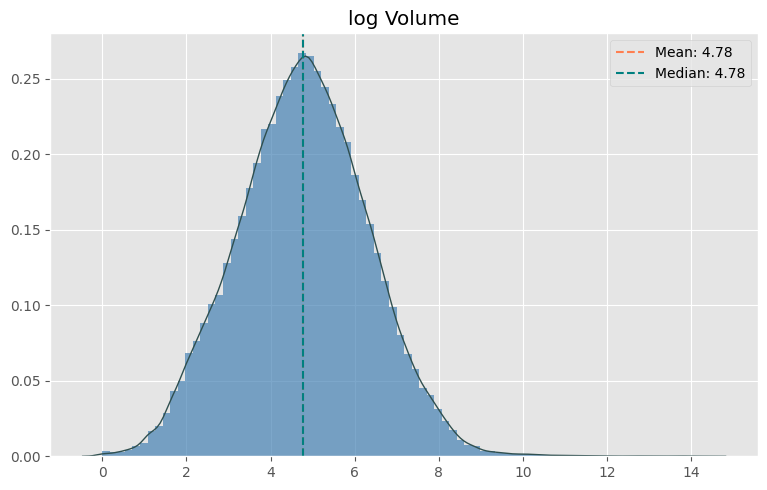

In [44]:
plot_hist_per_var(np.log1p(df[target].rename(f'log {target}')))

The distribution has a log-normal center and an elongated right tail → we apply the Yeo-Johnson target transformation to reduce the impact of extreme observations on the convergence of tree-based algorithms:

In [45]:
pt = PowerTransformer(method = 'yeo-johnson', standardize = False)
df[f'{target}_transformed'] = pt.fit_transform(df.pop(target).values.reshape(-1, 1))
target = f'{target}_transformed'

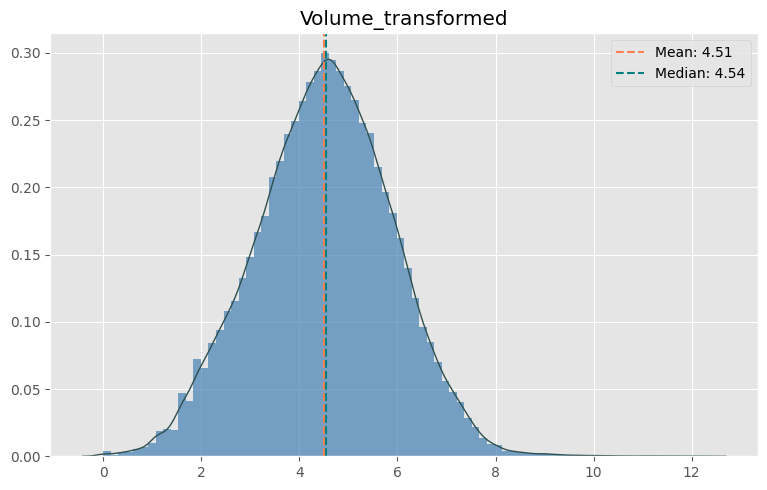

In [46]:
plot_hist_per_var(df[target])

In [47]:
df[target].describe()

,Volume_transformed
count,97348.000000
mean,4.506614
std,1.387443
min,-0.000000
25%,3.582107
50%,4.536034
75%,5.449024
max,12.272414


### Numerical features categorization, anomaly treatment

In [48]:
df[num_features].describe()

,CDE_Doors,Visit_Frequency
count,97348.000000,97348.000000
mean,1.074036,2.428917
std,0.884381,1.396590
min,0.000000,0.000000
25%,0.300000,2.000000
50%,1.000000,2.000000
75%,2.000000,2.000000
max,16.000000,45.000000


In [49]:
df[df['Visit_Frequency'] > 31]

,Office,Trade_Channel,Territory,Cust_Hier,Price_Group,Customer_Classific,CDE_Doors,Visit_Frequency,Potential,Volume_transformed
22866,Sakhalin/Kamchatka,Chain Convenience St,Far East,38616105,2,Supermarket,2.5,45.0,GO,4.071052
23233,Khabarovsk,Other Liquor/Beer/Wi,Far East,38211267,7,Supermarket,2.5,45.0,GO,6.492056


The maximum of 'Visit_Frequency' is anomalous and appears solely in the FE macro-region; we therefore replace it with the feature median computed over that macro-region:

In [50]:
df['Visit_Frequency'] = df['Visit_Frequency'].replace({45: df['Visit_Frequency'][(df['Territory'] == 'Far East') & (df['Visit_Frequency'] <= 31)].median()}).astype(float)

In [51]:
df['CDE_Doors'].nunique(), df['Visit_Frequency'].nunique()

(20, 11)

Given the low variability of the features, we categorize them for use in tree-based models:

In [52]:
categorized_num_features = [f'{feat}_cat' for feat in num_features]
df[categorized_num_features] = df[num_features].astype(str)

In [53]:
cat_features += categorized_num_features

### Categorical feature aggregation

In [54]:
threshold = 0.0001

print(f"Rare categories (< {threshold}% ~ {np.round(df.shape[0] * threshold, 1)} objects):", '=' * 200, sep = '\n', end = '\n\n')

for feat in cat_features:
    category_shares = df[feat].value_counts(normalize = True)
    rare_categories = category_shares[category_shares < threshold].index
    rare_categories_count = len(rare_categories)
    categories_count = df[feat].nunique()
    rare_categories_share = np.round(rare_categories_count / categories_count * 100, 1)
    if len(rare_categories) > 0:
       print(f"{feat} - {rare_categories_count}/{categories_count} ({rare_categories_share}%) cats:", f"{textwrap.fill(', '.join(rare_categories), width = 200)}", sep = '\n', end = '\n\n')

Rare categories (< 0.0001% ~ 9.7 objects):

Office - 2/52 (3.8%) cats:
McDonalds, SPB WHS

Trade_Channel - 1/58 (1.7%) cats:
Health/BIOFood Store

Price_Group - 1/38 (2.6%) cats:
26

Customer_Classific - 2/7 (28.6%) cats:
Pharmacy, Petrol

Cust_Hier - 117/361 (32.4%) cats:
38216309, 38216368, 38212218, 38140404, 38110101, 38212210, 38111004, 38212327, 38211256, 38130705, 38120302, 38634107, 38216349, 38633105, 38212330, 38216338, 38213321, 38110802, 38140204, 38211264,
38140203, 38130726, 38633104, 38120306, 38214313, 38631104, 38130320, 38110106, 38214322, 38512202, 38214201, 38216394, 38520108, 38216378, 38526109, 38213307, 38614101, 38216370, 38632101, 38215350,
38634106, 38130901, 38130607, 38216386, 38130931, 38514215, 38130921, 38211353, 38214344, 38130610, 38140412, 38216303, 38140312, 38211341, 38140329, 38211401, 38110809, 38631101, 38521106, 38310101,
38216363, 38216322, 38120209, 38130915, 38130608, 38216362, 38614107, 38520107, 38216393, 38140330, 38633102, 38140331, 382164

Ultra-rare categories (< 10 observations) are found in 8 out of 9 categorical features. To prevent model overfitting, we group these features based on the category semantics.

P.S. The target distribution is monitored across groups solely to verify their homogeneity during semantic grouping.

In [55]:
def plot_target_dist_per_category(df: pd.DataFrame, feat_name: str, target_name: str):
    categories = df.groupby(feat_name)[target_name].describe().sort_values(by = 'mean').index
    n_cols = 2
    n_rows = int(np.ceil(len(categories) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize = (14, 4 * n_rows))
    axes = axes.flatten()

    for i, (category, ax) in enumerate(zip(categories, axes)):
        category_mask = df[feat_name] == category
        ax.hist(df[category_mask][target_name], bins = 80, alpha = 0.7, color = 'steelblue', density = True)
        sns.kdeplot(df[category_mask][target_name], ax = axes[i], color = 'indianred', linewidth = 1, warn_singular = False)
        ax.set_title(f'{category}', fontsize = 12)
        ax.set_xlabel(f'n = {len(df[category_mask])}', fontsize = 10)
        ax.set_ylabel(None)

    for i in range(len(categories), len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()

In [56]:
def group_categories(feat: str, group_to_categories_map: dict):
    group_to_categories_map = {category: group
                               for group, categories in group_to_categories_map.items()
                               for category in categories}
    return df[feat].map(group_to_categories_map)

#### Office

In [57]:
df['Office'].value_counts().tail(10)

,count
Office,
Sevastopol,1308
Voronezh,1249
Sakhalin/Kamchatka,1142
Transportations-Sado,1127
Omsk,1077
Chechnya/Ingushetiya,454
E-com,106
WHS FC,14
McDonalds,9


In [58]:
df.groupby('Territory')['Office'].unique()

,Office
Territory,
Center E,"[Perm/Kirov/Komi, Sam/Tol/Syz-Kuz/Uliy, Kaz/Chel/Al/Cheb/Yos, Ufa/Izhevsk/Birsk, Strl/Ors/Orn/Buz/Bug]"
Center W,"[Ivan/Vlad/Yrsl/Kstrm, Kursk/Belgorod, Orl/Brnsk/Tula/Klg, NNovgorod/Saransk, Tamb/Lip/Pen/Ryazan]"
Far East,"[Vladivstk/Prim/Nakhd, Blagoveschensk-Yakut, Chita/Ulan-Ude, Khabarovsk, Sakhalin/Kamchatka]"
Moscow/Moscow Oblast,"[MRD West, City West, MRD East, City East, Transportations-Sado, E-com, McDonalds, WHS FC]"
North-West,"[SPB City, Kalin/Mnsk/Arkh/Ptrz, LenObl/Novg/Psk, Tver/Vologd/Smolensk, SPB WHS]"
Seacoast,"[Simferopol, Sevastopol, Krasnodar, Novoros/Anapa/Tuapse, Stavropol, Sochi/Adler/Abhaziya]"
Siberia,"[Barnaul, Novosibirsk, Abakan/Achinsk/Kansk, Irkutsk/Bratsk, Kmrv-Tmsk-Kuz, Krasnoyarsk/Norilsk]"
South,"[Volgograd/Saratov, GRP/Astrakhan/Elista, Rostov city/rural, Rostov reg/LNR/DNR, Dagestan, Voronezh, Chechnya/Ingushetiya]"
Ural,"[Chelyabinsk/Magnit, Nizhnevart/Surgut, Ekaterinburg/N.Tagil, Tyumen/Kurgan, Omsk]"


'WHS', 'E-com', and 'McDonalds' categories dilute the informativeness of the feature composed almost entirely of geographic categories; these entities therefore need to be localized.

Among the identified rare categories, only 'SPB WHS' is subject to semantic grouping:

In [59]:
df['Office_grouped'] = df['Office'].replace({'SPB WHS': 'SPB City'})
cat_features.remove('Office'); cat_features.append('Office_grouped')

#### Trade_Channel & Customer_Classific

In [60]:
df.groupby('Customer_Classific')['Trade_Channel'].unique()

,Trade_Channel
Customer_Classific,
E-com & Digital,"[Chain Convenience St, Digital, Other Liquor/Beer/Wi, Liquor/Beer/Wine, Superette, Other Supermarket, Petrol Market, Qsr-Local Food, Chain Petroleum Food, Other Petroleum-Food, Small trad food stor, Bakery, Box Store, Other Local & Tradit, Petrol Take Away, Qsr-Other Fast Food, Dairies, Other Hyper-Merchand, Grocery Kiosk, Coffee/Tea Shop, Caterer, Other Restaurant, Beverage Shop, Other Cash & Carry R, Fast-Food-Delivery]"
Foodservice & HoReCa,"[Qsr-Other Fast Food, Chain Convenience St, Liquor/Beer/Wine, Petrol Take Away, Other Local & Tradit, Kiosk/Newsstand, Kiosk/Food, Petrol Market, Caterer, Other Petroleum-Food, Other Primary/Second, Beverage Shop, Other Business And P, Produce Stand, Wholesaler, Grocery Kiosk, Cafe, Wholesaler Indirect, Superette, Small trad food stor, Butcher Shop, Bar, Bakery, Other Eating & Drink, Department Store, Coffee/Tea Shop, Hotel/Motel/Resort/I, Dairies, Books/Office/News/To, Sports/Country Club, Cart/Mobile Food, Other Contract Vendi, Other Supermarket, Chain Petroleum Food, Other Liquor/Beer/Wi, Qsr-Bakery, Railroad, Other Restaurant, Airline, Break Corner, Fast-Food-Delivery, Digital, Pastry, Premium Gastronomy, Box Store, Electronic Game Cent, Qsr-Local Food, Nightclub, Cinema/Movie, Beauty & Personal Ca, Other Drug Store, Other Cash & Carry R, Open Market]"
Petrol,"[Small trad food stor, Premium Gastronomy]"
Pharmacy,"[Other Liquor/Beer/Wi, Small trad food stor, Other Local & Tradit, Chain Convenience St]"
Supermarket,"[Kiosk/Food, Small trad food stor, Butcher Shop, Grocery Kiosk, Other Local & Tradit, Bakery, Department Store, Dairies, Qsr-Other Fast Food, Pastry, Other Liquor/Beer/Wi, Beverage Shop, Chain Convenience St, Petrol Market, Other Business And P, Caterer, Qsr-Local Food, Produce Stand, Cafe, Petrol Take Away, Break Corner, Cart/Mobile Food, Hawking Hub Wholesal, Bar, Superette, Books/Office/News/To, Kiosk/Newsstand, Liquor/Beer/Wine, Hotel/Motel/Resort/I, Qsr-Bakery, Other Restaurant, Other Eating & Drink, Other Cash & Carry R, Nightclub, Open Market, Premium Gastronomy, Beauty & Personal Ca, Other Supermarket, Sports/Country Club, Fast-Food-Delivery, Cinema/Movie, Other Primary/Second, Chain Petroleum Food, Coffee/Tea Shop, Electronic Game Cent, Box Store, Other Drug Store, Wholesaler, Wholesaler Indirect, Other Petroleum-Food, Airline, FSR-Local, Cruise Ship Line, Railroad, Other Contract Vendi, Other Hyper-Merchand, Health/BIOFood Store, Digital]"
Traditional,"[Break Corner, Qsr-Other Fast Food, Coffee/Tea Shop, Nightclub, Cinema/Movie, Kiosk/Food, Petrol Take Away, Department Store, Cafe, Books/Office/News/To, Petrol Market, Grocery Kiosk, Other Local & Tradit, Other Business And P, Small trad food stor, Caterer, Other Restaurant, Dairies, Chain Convenience St, Hotel/Motel/Resort/I, Other Petroleum-Food, Premium Gastronomy, Kiosk/Newsstand, Bar, Liquor/Beer/Wine, Sports/Country Club, Qsr-Bakery, Other Primary/Second, Other Liquor/Beer/Wi, Electronic Game Cent, Other Eating & Drink, Cart/Mobile Food, Fast-Food-Delivery, Beverage Shop, Pastry, Open Market, Produce Stand, Bakery, Butcher Shop, Other Contract Vendi, Chain Petroleum Food, Wholesaler, FSR-Local, Other Drug Store, Beauty & Personal Ca, Qsr-Local Food, Cruise Ship Line, Other Hyper-Merchand, Superette, Airline, Other Supermarket, Wholesaler Indirect]"
Wholesale,"[Other Local & Tradit, Department Store, Qsr-Other Fast Food, Small trad food stor, Chain Convenience St, Liquor/Beer/Wine, Other Eating & Drink, Dairies, Cafe, Kiosk/Newsstand, Butcher Shop, Qsr-Bakery, Caterer, Petrol Take Away, Cinema/Movie, Bar, Kiosk/Food, Grocery Kiosk, Bakery, Electronic Game Cent, Books/Office/News/To, Other Business And P, Pastry, Fast-Food-Delivery, Petrol Market, Beverage Shop, Sports/Country Club, Other Restaurant, Coffee/Tea Shop, Break Corner, Other Petroleum-Food, Other Contract Vendi, Beauty & Personal Ca, Hotel/Motel/Resort/I, Other Primary/Second, FSR-Local, Produce S

The 'Customer_Classific' and 'Trade_Channel' features represent different levels of FMCG customer classification: semantically, the 'Trade_Channel' categories detail the 'Customer_Classific' groups. However, instead of a clear grouping, we observe anomalies in the data, in particular:

<ins>Massive category overlap</ins> — 'Small trad food stor' shows up in 6 of the 7 groups; 'Chain Convenience St', 'Liquor/Beer/Wine', 'Cafe', and dozens more appear in 4–6 groups.

<ins>Loss of semantic value</ins> — 'Bakery' and 'Petrol Take Away' are simultaneously assigned to the 'Supermarket', 'Traditional', and 'Foodservice' groups, which undermines the explanatory power of the 'Customer_Classific' feature (and, by extension, of models trained with it).

<ins>Uninformative groups</ins> — 'Petrol' contains 'Small trad food stor' and 'Premium Gastronomy' but not 'Petrol Market' or 'Chain Petroleum Food'; 'Pharmacy' contains 'Other Local & Tradit', 'Other Liquor/Beer/Wi', 'Chain Convenience St', and 'Small trad food stor' but not 'Other Drug Store'.

The pattern of these anomalies may point to aggregation errors introduced during the construction of the 'Customer_Classific' groups. As an alternative to the noisy feature, we group the low-frequency 'Trade_Channel' categories by business model and supply chain specifics:

In [61]:
df['Trade_Channel'].value_counts().tail(10)

,count
Trade_Channel,
Other Cash & Carry R,115
FSR-Local,93
Other Drug Store,68
Hawking Hub Wholesal,44
Other Hyper-Merchand,35
Airline,25
Railroad,18
Wholesaler Indirect,13
Cruise Ship Line,13


In [62]:
df['Trade_Channel_grouped'] = df['Trade_Channel'].replace({'Beverage Shop': 'Beverage Shop & BIO', 'Health/BIOFood Store': 'Beverage Shop & BIO',
                                                           'Other Supermarket': 'Other Supermarket & Hyper', 'Other Hyper-Merchand': 'Other Supermarket & Hyper',
                                                           'Wholesaler Indirect': 'Wholesaler', 'Other Cash & Carry R': 'CC & Hawking Hub', 'Hawking Hub Wholesal': 'CC & Hawking Hub',
                                                           'Airline': 'Airline, Railroad & Cruise Line', 'Railroad': 'Airline, Railroad & Cruise Line', 'Cruise Ship Line': 'Airline, Railroad & Cruise Line'})

cat_features = [feat for feat in cat_features if feat not in ['Trade_Channel','Customer_Classific']]
cat_features.append('Trade_Channel_grouped')



In [63]:
plot_target_dist_per_category(df, 'Trade_Channel_grouped', target)

The bimodal target distribution for 'Chain Convenience St' may point to heterogeneity or data contamination (systematic entry errors). Both hypotheses should be verified on a larger dataset — or directly with the data source.

#### Price_Group

In [64]:
df['Price_Group'].value_counts().tail(10)

,count
Price_Group,
51,191
36,189
38,145
54,129
16,115
91,103
25,68
40,46
6,35


In [65]:
df['Price_Group_grouped'] = df['Price_Group'].replace({'6':'6-7', '7':'6-7', '24':'24-26', '25':'24-26', '26':'24-26', '40':'40-41', '41':'40-41'})
cat_features.remove('Price_Group'); cat_features.append('Price_Group_grouped')

#### Potential

In [66]:
df['Potential'].value_counts()

,count
Potential,
BR,29965
IR,21354
SI,16295
PL,14941
GO,10839
Other,2149
New Customer,1804
NOT SEGMENTED,1


In [67]:
potential_stats = df.groupby('Potential')[target].describe()
(potential_stats['std'] / potential_stats['mean']).rename('cv')

,cv
Potential,
BR,0.216224
GO,0.266558
IR,0.281436
NOT SEGMENTED,NaN
New Customer,0.399936
Other,0.359436
PL,0.166260
SI,0.258932


'NOT SEGMENTED' is a stand-alone category with no semantic relation to any of the others. We merge it with 'Other', which — based on the coefficient of variation of the target — is a "garbage" category:

In [68]:
df['Potential'] = df['Potential'].replace({'NOT SEGMENTED':'Other'})

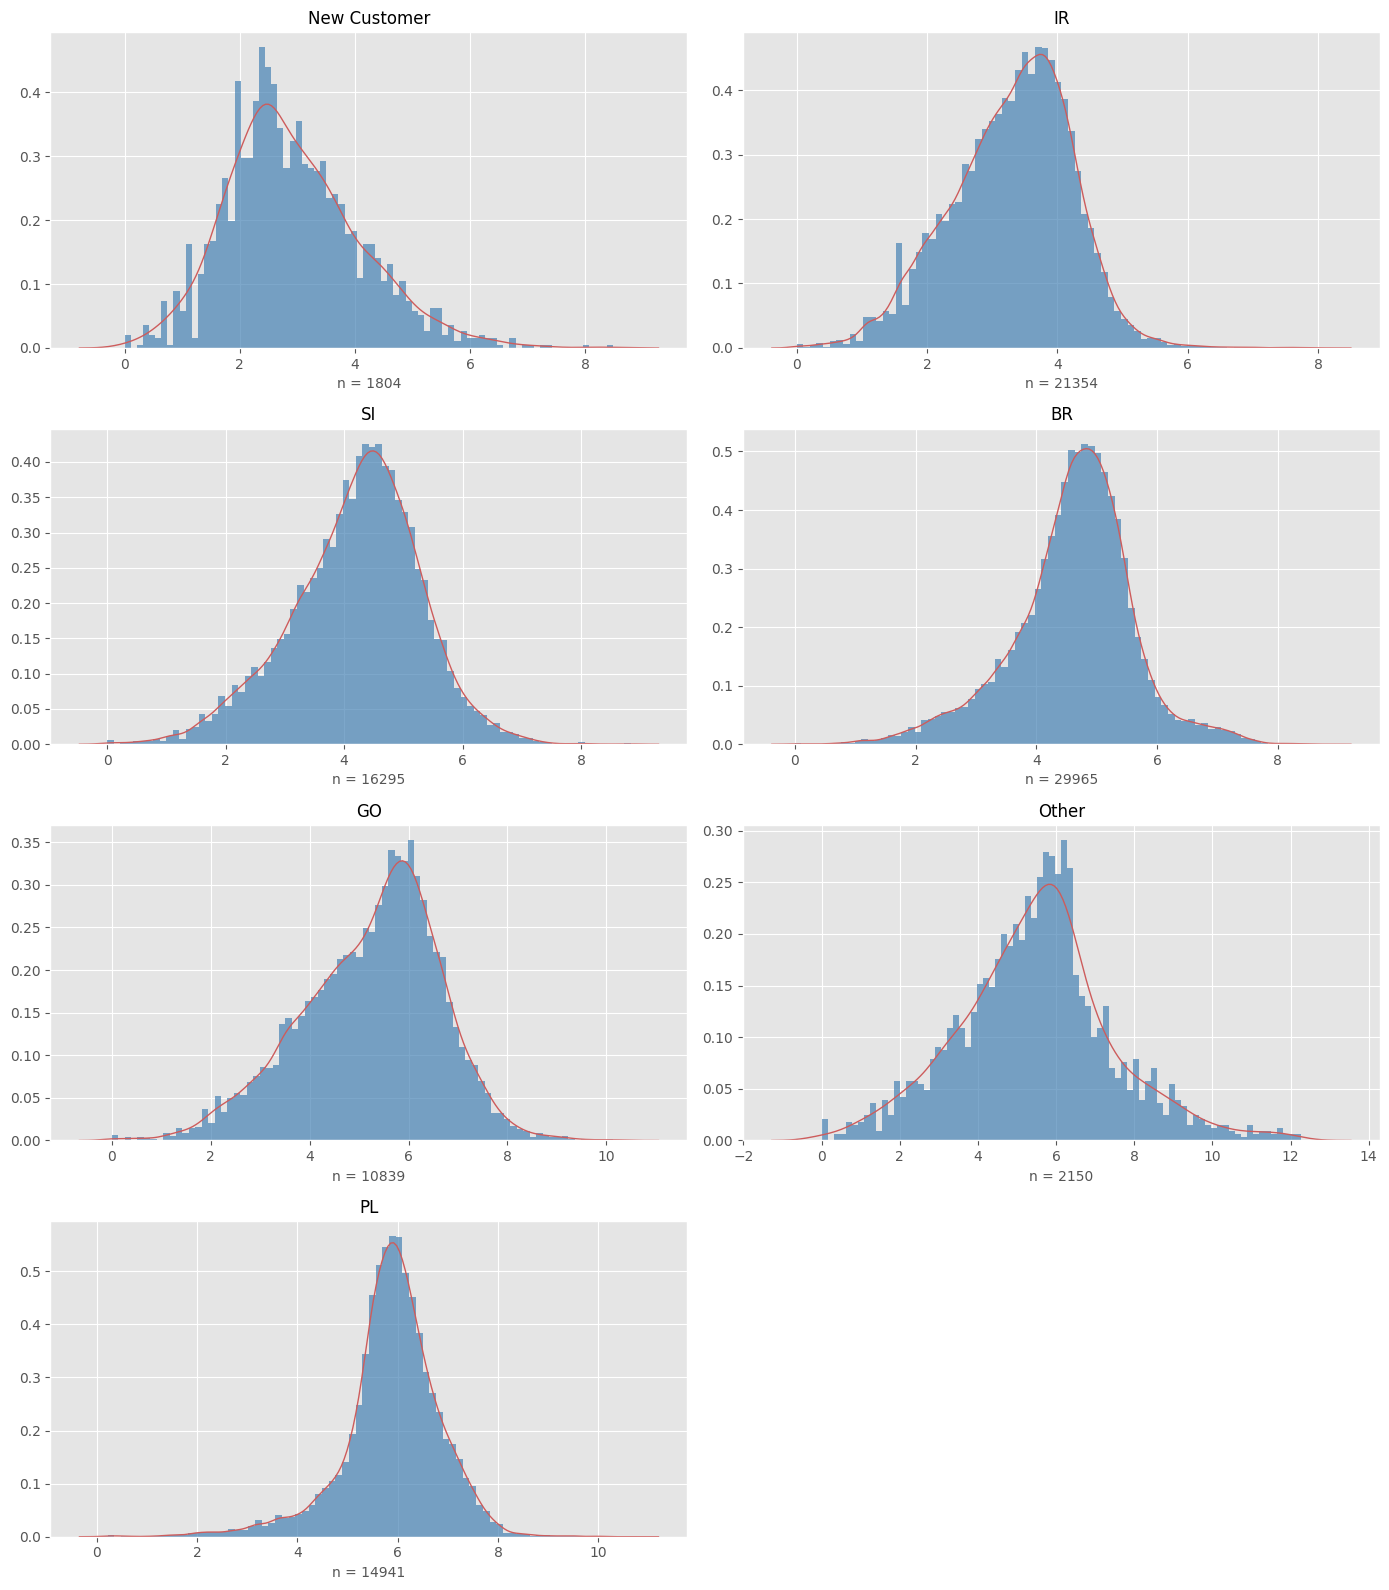

In [69]:
plot_target_dist_per_category(df, 'Potential', target)

In [70]:
df.groupby('Potential')[target].describe().sort_values(by = '50%')

,count,mean,std,min,25%,50%,75%,max
Potential,,,,,,,,
New Customer,1804.0,2.926647,1.170473,-0.000000,2.124608,2.770111,3.615151,8.487962
IR,21354.0,3.296395,0.927723,-0.000000,2.692180,3.394068,3.945963,8.123855
SI,16295.0,4.203285,1.088366,-0.000000,3.545512,4.309270,4.926559,8.839473
BR,29965.0,4.607957,0.996349,-0.000000,4.099197,4.699600,5.205977,8.829604
GO,10839.0,5.241799,1.397243,-0.000000,4.338502,5.444307,6.208262,10.399649
Other,2150.0,5.475669,1.969025,-0.000000,4.277480,5.546704,6.486188,12.272414
PL,14941.0,5.881830,0.977911,0.085178,5.454553,5.932366,6.441775,10.770206


The 'Other' category should be disaggregated according to the clusters identified. Its likely subcategories are 'GO' (given the similarity of target shapes and summary stats) and 'Key Account' (to capture the elongated right tail of the target distribution).

#### CDE_Doors_cat

In [71]:
df['CDE_Doors_cat'].value_counts().tail(10)

,count
CDE_Doors_cat,
6.0,53
2.5,34
16.0,17
1.4,11
1.7,9
7.0,5
3.5,5
15.0,4
0.25,2


In [72]:
CDE_Doors_groups = {'0.0': ['0.0'], '0.25-0.3': ['0.25','0.3'], '0.5': ['0.5'], '0.7': ['0.7'],
                    '1.0': ['1.0'], '1.4-1.7': ['1.4','1.5','1.7'], '2.0-2.5': ['2.0','2.5'],
                    '2.7': ['2.7'], '3.0-3.5': ['3.0','3.5'], '≥ 4.0': ['4.0','5.0','6.0','7.0','15.0','16.0']}

df['CDE_Doors_grouped'] = group_categories('CDE_Doors_cat', CDE_Doors_groups)
cat_features.remove('CDE_Doors_cat'); cat_features.append('CDE_Doors_grouped')

#### Visit_Frequency_cat

In [73]:
df['Visit_Frequency_cat'].value_counts()

,count
Visit_Frequency_cat,
2.0,55728
4.0,21500
1.0,16757
8.0,2749
0.0,384
0.5,167
0.2,51
2.5,6
10.0,4


In [74]:
df['Visit_Frequency_grouped'] = df['Visit_Frequency_cat'].replace({'2.0':'2.0-2.5', '2.5':'2.0-2.5', '3.5':'3.5-4.0', '4.0':'3.5-4.0', '7.0':'≥ 7.0', '8.0':'≥ 7.0', '10.0':'≥ 7.0'})
cat_features.remove('Visit_Frequency_cat'); cat_features.append('Visit_Frequency_grouped')

## Feature space expansion

Drawing on information about the geographic location of customers (the 'Office' feature), we generate features that characterize the socioeconomic standing, industry profile, and climatic conditions of the regions (sourced from open statistical data):

* Proportion of the population below the median per capita income threshold (a proxy for purchasing power)

* Average consumer prices in the "sparkling soft drinks" category

* Share of "sparkling soft drinks" in household consumption expenditure

* Retail turnover of food products, including beverages, and tobacco products

* Share of the young population (aged 14–35)

* Average monthly temperature for July

* Number of persons accommodated in collective accommodation establishments (an indicator of the region's recreational appeal)

### Normalization of 'Office' categories

In [75]:
df.groupby('Territory')['Office_grouped'].unique()

,Office_grouped
Territory,
Center E,"[Perm/Kirov/Komi, Sam/Tol/Syz-Kuz/Uliy, Kaz/Chel/Al/Cheb/Yos, Ufa/Izhevsk/Birsk, Strl/Ors/Orn/Buz/Bug]"
Center W,"[Ivan/Vlad/Yrsl/Kstrm, Kursk/Belgorod, Orl/Brnsk/Tula/Klg, NNovgorod/Saransk, Tamb/Lip/Pen/Ryazan]"
Far East,"[Vladivstk/Prim/Nakhd, Blagoveschensk-Yakut, Chita/Ulan-Ude, Khabarovsk, Sakhalin/Kamchatka]"
Moscow/Moscow Oblast,"[MRD West, City West, MRD East, City East, Transportations-Sado, E-com, McDonalds, WHS FC]"
North-West,"[SPB City, Kalin/Mnsk/Arkh/Ptrz, LenObl/Novg/Psk, Tver/Vologd/Smolensk]"
Seacoast,"[Simferopol, Sevastopol, Krasnodar, Novoros/Anapa/Tuapse, Stavropol, Sochi/Adler/Abhaziya]"
Siberia,"[Barnaul, Novosibirsk, Abakan/Achinsk/Kansk, Irkutsk/Bratsk, Kmrv-Tmsk-Kuz, Krasnoyarsk/Norilsk]"
South,"[Volgograd/Saratov, GRP/Astrakhan/Elista, Rostov city/rural, Rostov reg/LNR/DNR, Dagestan, Voronezh, Chechnya/Ingushetiya]"
Ural,"[Chelyabinsk/Magnit, Nizhnevart/Surgut, Ekaterinburg/N.Tagil, Tyumen/Kurgan, Omsk]"


The 'Office' categories are administrative-territorial units of various levels and their clusters, including mixed ones (Perm/Kirov/Komi, Sochi/Adler/Abkhazia, etc.).

To group them, we need to normalize the 'Office' categories as follows:

1. Remove uninformative subcategories:

  * GRP — cannot be interpreted;

  * Adler — a district of Sochi, part of the same mixed cluster;

  * Abkhazia — not an administrative-territorial unit of the Russian Federation;

  * LNR, DNR — no reliable statistical data available.

2. Decode and translate the administrative-territorial labels into Russian.

3. Convert city names to their corresponding regions.

In [76]:
df['Office_region'] = df['Office_grouped'].str.replace(r'\s*/*(GRP|Adler|Abhaziya|LNR|DNR)/*\s*', '/', regex = True, flags = re.IGNORECASE).str.strip(r'/')

df['Office_region'] = df['Office_region'].replace({

'Perm/Kirov/Komi':'Perm/Kirov/Komi Republic', 'Sam/Tol/Syz-Kuz/Uliy':'Samara/Tolyatti/Syzran-Kuznetsk/Ulyanovsk', 'Kaz/Chel/Al/Cheb/Yos':'Kazan/Naberezhnye Chelny/Almetyevsk/Cheboksary/Yoshkar-Ola',
'Strl/Ors/Orn/Buz/Bug':'Sterlitamak/Orsk/Orenburg/Buzuluk/Buguruslan', 'Ivan/Vlad/Yrsl/Kstrm':'Ivanovo/Vladimir/Yaroslavl/Kostroma', 'Orl/Brnsk/Tula/Klg':'Oryol/Bryansk/Tula/Kaluga',
'NNovgorod/Saransk':'Nizhny Novgorod/Saransk', 'Tamb/Lip/Pen/Ryazan':'Tambov/Lipetsk/Penza/Ryazan', 'Vladivstk/Prim/Nakhd':'Vladivostok/Primorsky Krai/Nakhodka', 'Blagoveschensk-Yakut':'Blagoveshchensk-Yakutsk',
'Sakhalin/Kamchatka':'Sakhalin Oblast/Kamchatka Krai', 'SPB City':'Saint Petersburg', 'Kalin/Mnsk/Arkh/Ptrz':'Kaliningrad/Murmansk/Arkhangelsk/Petrozavodsk',
'LenObl/Novg/Psk':'Leningrad Oblast/Veliky Novgorod/Pskov', 'Tver/Vologd/Smolensk':'Tver/Vologda/Smolensk', 'Novoros/Anapa/Tuapse':'Novorossiysk/Anapa/Tuapse', 'Kmrv-Tmsk-Kuz':'Kemerovo-Tomsk-Novokuznetsk',
'Rostov city/rural':'Rostov-on-Don', 'Rostov reg':'Rostov Oblast', 'Chechnya/Ingushetiya':'Chechen Republic/Ingushetia', 'Chelyabinsk/Magnit':'Chelyabinsk/Magnitogorsk', 'Nizhnevart/Surgut':'Nizhnevartovsk/Surgut',
'Ekaterinburg/N.Tagil':'Yekaterinburg/Nizhny Tagil', 'MRD West':'Moscow Oblast', 'MRD East':'Moscow Oblast', 'City West':'Moscow', 'City East':'Moscow',
'Transportations-Sado':'Moscow', 'E-com':'Moscow', 'McDonalds':'Moscow', 'WHS FC':'Moscow'})

In [77]:
def GET(url: str):
    warnings.filterwarnings('ignore')

    parsed_url = urlparse(url)
    start_page = f"{parsed_url.scheme}://{parsed_url.netloc}"

    session = Session()
    session.headers.update({'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36',
                            'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8',
                            'Accept-Language': 'ru-RU,ru;q=0.9,en-US;q=0.8,en;q=0.7',
                            'Accept-Encoding': 'gzip, deflate, br',
                            'Connection': 'keep-alive',
                            'Upgrade-Insecure-Requests': '1',
                            'Referrer': start_page})

    session.get(start_page, timeout = 10, verify = False) # fetching the landing page to retrieve cookies
    response = session.get(url, timeout = 30, verify = False)

    return response

In [78]:
# constructing a RU–EN lookup table of cities and regions
regions_df = pd.DataFrame(GET('https://raw.githubusercontent.com/arbaev/russia-cities/master/russia-regions.json').json())
cities_df = pd.DataFrame(GET('https://raw.githubusercontent.com/arbaev/russia-cities/master/russia-cities.json').json())

cities_df['OKATO_region'] = cities_df['okato'].str[:2]
regions_df['OKATO_region'] = regions_df['okato'].str[:2]

cities_regions_df = pd.merge(cities_df[['name','name_en','OKATO_region']], regions_df[['fullname','name_en','OKATO_region']],
                             on = 'OKATO_region', how = 'left', suffixes = ('_city','_region')).\
                             rename(columns = {'name':'name_ru_city', 'fullname':'name_ru_region'})

cities_regions_df = pd.concat((cities_regions_df,
                               pd.DataFrame([{'name_ru_city': 'Симферополь', 'name_en_city': 'Simferopol', 'OKATO_region': '35',
                                              'name_ru_region': 'Республика Крым', 'name_en_region': 'Republic of Crimea'},
                                             {'name_ru_city': 'Севастополь', 'name_en_city': 'Sevastopol', 'OKATO_region': '67',
                                              'name_ru_region': 'Севастополь', 'name_en_region': 'Sevastopol'},])),
                              ignore_index = True)

# handling irregular region name entries: Sakha /Yakutia/ → Sakha (Yakutia)
cities_regions_df['name_ru_region'] = cities_regions_df['name_ru_region'].str.replace(r'(.*?)/(.*?)/', r'\1(\2)', regex = True)

cities_regions_df.head(1)

,name_ru_city,name_en_city,OKATO_region,name_ru_region,name_en_region
0,Ишимбай,Ishimbay,80,Республика Башкортостан,Republic of Bashkortostan


In [79]:
city_names_en = cities_regions_df['name_en_city'].unique()
region_names_en = cities_regions_df['name_en_region'].unique()

category_clusters = [re.split('/', category) for category in df['Office_region'].unique()]
region_clusters_ru = []

def map_en_city_region_to_ru_region(category: str):
    if category in city_names_en:
       return cities_regions_df.loc[cities_regions_df['name_en_city'] == category, 'name_ru_region'].iloc[0]
    if category in region_names_en:
       return cities_regions_df.loc[cities_regions_df['name_en_region'] == category, 'name_ru_region'].iloc[0]

for cluster in category_clusters:
    cluster_regions_ru = set() # deduplicating regions within clusters
    for category in cluster:
        if not '-' in category:
           ru_region = map_en_city_region_to_ru_region(category)
           if ru_region:
              cluster_regions_ru.add(ru_region)
           else:
                raise RuntimeError(f"Category '{category}' is not found in the lookup table")
        else:
             ru_region = map_en_city_region_to_ru_region(category)
             if ru_region:
                cluster_regions_ru.add(ru_region)
             else:
                  split_category = re.split('-', category)
                  for part in split_category:
                      ru_region = map_en_city_region_to_ru_region(part)
                      if ru_region:
                         cluster_regions_ru.add(ru_region)
                      else:
                           raise RuntimeError(f"Category '{category}' is not found in the lookup table")
    region_clusters_ru.append(list(cluster_regions_ru))

In [80]:
df['Office_region'] = df['Office_region'].replace(dict(zip(df['Office_region'].unique(), ['/'.join(cluster) for cluster in region_clusters_ru])))

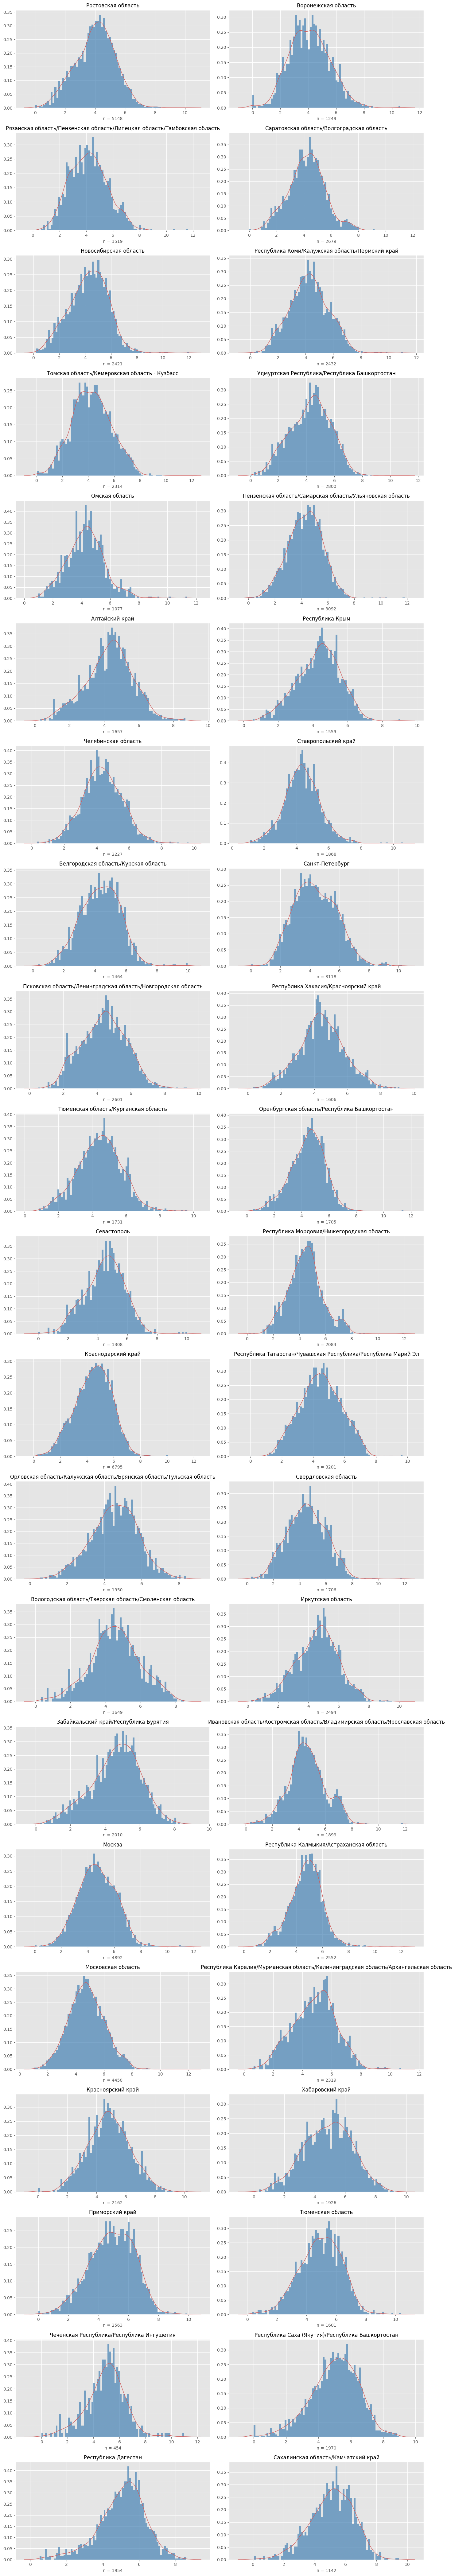

In [ ]:
plot_target_dist_per_category(df, 'Office_region', target)

The bimodal target distribution for some clusters suggests that the grouping is suboptimal. The 'Office' feature should therefore be disaggregated to the level of individual city names at the data collection stage.

### Feature construction

In [81]:
region_clusters_ru = [re.split('/', category) for category in df['Office_region'].unique()]

In [82]:
def load_excel_from_url(url, sheet_name = 0):

    assert isinstance(sheet_name, (str, list, int)), f"Allowed 'sheet_name' types - str, list и int"

    response = GET(url)
    if response.status_code == 200:
       try:
           return pd.read_excel(response.content, sheet_name = sheet_name)
       except Exception as e:
              raise RuntimeError(e)
    else:
         raise RuntimeError(f"Failed to fetch '{url}', error code: {response.status_code}")

In [83]:
# used for weighted statistics computation only, doesn't consitute a standalone feature
population_df = load_excel_from_url('https://rosstat.gov.ru/storage/mediabank/BUL_MO_2024.xlsx', 'Таб_1')\
                                   .iloc[:, :2].dropna(axis = 0, how = 'any')\
                                   .rename(columns = {'Содержание':'Region', 'Unnamed: 1':'Население'}).astype({'Население': int})

In [ ]:
def create_statistic_feat(target_df,
                          population_df, population_region_col = 'Region', population_indicator_col = 'Население',
                          statistic_df = None, statistic_region_col = 'Region', statistic_indicator_col = 'Показатель',
                          aggregation_type = 'mean'):

    assert aggregation_type in ['mean','sum'], f"Allowed 'aggregation_type' values - 'mean' и 'sum'"

    unique_regions = set([region for cluster in region_clusters_ru for region in cluster])
    populations_per_region, stats_per_region = {},{}

    def get_region_statistic(region_name, df, region_col, statistic_col):
        try:
            return df.loc[df[region_col] == region_name, statistic_col].iloc[0]
        except IndexError:
               fuzzy_match = process.extractOne(region_name, df[region_col].unique(), scorer = fuzz.partial_ratio, score_cutoff = 80)
               if fuzzy_match:
                  return df.loc[df[region_col] == fuzzy_match[0], statistic_col].iloc[0]
               else:
                    raise RuntimeError(f"'{region_name}' is not found in the lookup table")

    for region in unique_regions:
        populations_per_region[region] = get_region_statistic(region, population_df, population_region_col, population_indicator_col)
        if statistic_df is not None:
           stats_per_region[region] = get_region_statistic(region, statistic_df, statistic_region_col, statistic_indicator_col)

    stats_by_cluster = {}

    if statistic_df is None: # by default, we sum the population over the cluster
       for cluster in region_clusters_ru:
           cluster_population = np.sum([populations_per_region[reg] for reg in cluster])
           cluster_name = cluster[0] if len(cluster) == 1 else '/'.join(cluster)
           stats_by_cluster[cluster_name] = cluster_population
    else:
         for cluster in region_clusters_ru:
             cluster_name = cluster[0] if len(cluster) == 1 else '/'.join(cluster)

             if len(cluster) == 1:
                stats_by_cluster[cluster_name] = stats_per_region[cluster[0]]
             else:
                  if aggregation_type == 'mean':
                     total_pop = np.sum([populations_per_region[reg] for reg in cluster])
                     weighted_sum = np.sum([stats_per_region[reg] * pop_pop_val for reg, pop_pop_val in [(r, populations_per_region[r]) for r in cluster]])
                     stats_by_cluster[cluster_name] = weighted_sum / total_pop
                  else:
                       stats_by_cluster[cluster_name] = np.sum([stats_per_region[reg] for reg in cluster])

    return target_df['Office_region'].map(pd.Series(stats_by_cluster, dtype = float))

#### Proportion of the population below the median per capita income threshold

In [ ]:
below_med_income_share_df = load_excel_from_url('https://rosstat.gov.ru/storage/mediabank/Nb_Smm_1-2-10.xlsx', 'субъекты РФ 2024')

below_med_income_share_df = below_med_income_share_df.drop(columns = [below_med_income_share_df.columns[1]] + list(below_med_income_share_df.columns[3:])).dropna(how = 'any')\
                                                     .rename(columns = {'Доля населения, имеющего среднедушевые денежные доходы ниже границы медианного среднедушевого денежного дохода населения в 2024 году': 'Region',
                                                                        'Unnamed: 2': 'Показатель'}).astype({'Показатель': float})

df['Below_median_income_share'] = create_statistic_feat(df, population_df = population_df, statistic_df = below_med_income_share_df)
num_features.append('Below_median_income_share')

#### Average consumer prices in the "sparkling soft drinks" category

In [ ]:
avg_prices_df = load_excel_from_url('https://rosstat.gov.ru/storage/mediabank/sred_potreb_cen_12-2025.xlsx', '12(2024)')

avg_prices_df = avg_prices_df.drop(columns = [avg_prices_df.columns[0]] + list(avg_prices_df.columns[2:127]) + list(avg_prices_df.columns[128:])).dropna(how = 'any').iloc[1:]\
                             .rename(columns = {'Unnamed: 1':'Region', 'Unnamed: 127':'Показатель'}).astype({'Показатель': float})

df['Avg_SSD_prices'] = create_statistic_feat(df, population_df = population_df, statistic_df = avg_prices_df)
num_features.append('Avg_SSD_prices')

#### Share of "sparkling soft drinks" in household consumption expenditure

In [ ]:
SSD_consumption_share_df = load_excel_from_url('https://rosstat.gov.ru/storage/mediabank/CPR_SUB_2025.xlsx', '2025')

SSD_consumption_share_df = SSD_consumption_share_df.drop(index = [SSD_consumption_share_df.index[1]] + list(SSD_consumption_share_df.index[2:129]) + list(SSD_consumption_share_df.index[130:]))\
                                                   .transpose().reset_index(drop = True).iloc[2:].rename(columns = {0:'Region', 129:'Показатель'}).astype({'Показатель': float})

df['SSD_consumption_share'] = create_statistic_feat(df, population_df = population_df, statistic_df = SSD_consumption_share_df)
num_features.append('SSD_consumption_share')

#### Retail turnover of food products, including beverages, and tobacco products

In [ ]:
food_retail_turnover_sheets = load_excel_from_url('https://www.rosstat.gov.ru/storage/mediabank/prod_rinky_2024.xls', ['1','2'])
food_retail_turnover_df = None

for sheet in food_retail_turnover_sheets:
    temp_df = food_retail_turnover_sheets[sheet]
    temp_df = temp_df.drop(columns = temp_df.columns[1:5]).dropna(how = 'any')\
                                            .rename(columns = {'К содержанию':'Region', 'Unnamed: 5':'Показатель'}).set_index('Region').astype(float)
    if food_retail_turnover_df is None:
       food_retail_turnover_df = temp_df
    else:
         food_retail_turnover_df = food_retail_turnover_df.add(temp_df, fill_value = 0)

food_retail_turnover_df = food_retail_turnover_df.reset_index()

df['Food_retail_turnover'] = create_statistic_feat(df, population_df = population_df, statistic_df = food_retail_turnover_df, aggregation_type = 'sum')
num_features.append('Food_retail_turnover')

#### Share of the young population (aged 14–35)

In [ ]:
population_by_age_df = load_excel_from_url('https://rosstat.gov.ru/storage/mediabank/Chisl_polvozr_01-01-2022_VPN-2020.xlsx')
population_by_age_df = population_by_age_df.drop(columns = list(population_by_age_df.columns[2:5]) + list(population_by_age_df.columns[106:])).dropna(how = 'any')\
                                           .rename(columns = dict(zip([f'Unnamed: {i}' for i in range(2)] + [f'Unnamed: {i}' for i in range(5, 106)],
                                                                      ['Region','Общая численность населения','до 1'] + [f"{i}" for i in range(1,101)])))
for col in population_by_age_df.iloc[:, 1:]:
    population_by_age_df[col] = population_by_age_df[col].replace('–', 0).astype(int)

population_by_age_df['Показатель'] = population_by_age_df.loc[:,'14':'35'].sum(axis = 1) / population_by_age_df['Общая численность населения'] * 100

df['Youth_share'] = create_statistic_feat(df, population_df = population_df, statistic_df = population_by_age_df)
num_features.append('Youth_share')

#### Average monthly temperature for July

In [ ]:
avg_july_temp_df = load_excel_from_url('https://www.rosstat.gov.ru/storage/mediabank/kl-8_2024.xlsx')\
                                      .drop(columns = ['Unnamed: 1','Unnamed: 2','Unnamed: 4']).dropna(how = 'any')\
                                      .rename(columns = {'Обновлено июнь 2025 г.':'Region', 'Unnamed: 3':'Показатель'}).astype({'Показатель': float})

df['Avg_July_temperature'] = create_statistic_feat(df, population_df = population_df, statistic_df = avg_july_temp_df)
num_features.append('Avg_July_temperature')

#### Number of persons accommodated in collective accommodation establishments

In [ ]:
ksr_headcount_df = load_excel_from_url('https://www.rosstat.gov.ru/storage/mediabank/KSR_mes_sub_11-2025.xlsx', '1.2024')
ksr_headcount_df = ksr_headcount_df.drop(columns = ksr_headcount_df.columns[1:12]).dropna(how = 'any')\
                                   .rename(columns = {'К содержанию':'Region', 'Unnamed: 12': 'Показатель'}).astype({'Показатель': int})

df['KSR_headcount'] = create_statistic_feat(df, population_df = population_df, statistic_df = ksr_headcount_df, aggregation_type = 'sum')
num_features.append('KSR_headcount')

# Model development (CatBoostRegressor)

## Feature selection

In [ ]:
seed = 42

X = df[num_features + cat_features]
y = df[target]

for feat in cat_features:
    X[feat] = X[feat].astype('category')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2, random_state = seed)

train_pool = Pool(X_train, y_train, cat_features = cat_features, feature_names = list(X_train.columns))
test_pool = Pool(X_test, y_test, cat_features = cat_features, feature_names = list(X_test.columns))

In [ ]:
fs_model =  CatBoostRegressor(iterations = 300,
                              learning_rate = 0.1,
                              bootstrap_type = 'MVS',
                              loss_function = 'MAE',
                              eval_metric = 'MAE',
                              cat_features = cat_features,
                              depth = 8,
                              min_data_in_leaf = 5,
                              l2_leaf_reg = 3,
                              max_ctr_complexity = 5,
                              one_hot_max_size = 10,
                              random_strength = 1,
                              random_seed = seed,
                              early_stopping_rounds = 100,
                              allow_writing_files = False,
                              use_best_model = True)

fs_model.fit(X_train, y_train, eval_set = test_pool, verbose = 100)

0:	learn: 1.0509548	test: 1.0443501	best: 1.0443501 (0)	total: 194ms	remaining: 58.1s
100:	learn: 0.6626827	test: 0.6780473	best: 0.6780473 (100)	total: 11.3s	remaining: 22.3s
200:	learn: 0.6414561	test: 0.6681780	best: 0.6681780 (200)	total: 22.5s	remaining: 11.1s
299:	learn: 0.6292774	test: 0.6650709	best: 0.6650647 (298)	total: 33s	remaining: 0us

bestTest = 0.6650647049
bestIteration = 298

Shrink model to first 299 iterations.


In [ ]:
fs_model.get_feature_importance(prettified = True)

,Feature Id,Importances
0,Потенциал,34.336467
1,Trade_Channel_grouped,15.843913
2,Cust_Hier,10.956746
3,Price_Group_grouped,6.590016
4,CDE_Doors_grouped,6.013789
5,CDE_Doors,5.233061
6,Office_grouped,4.820150
7,Visit_Frequency_grouped,3.547372
8,Visit_Frequency,3.015734
9,Below_median_income_share,1.678935


In [ ]:
def top_n_interactions(model, X, n = 10):
    interactions = model.get_feature_importance(prettified = True, type = 'Interaction').rename(columns = {'First Feature Index':'1st feature', 'Second Feature Index':'2nd feature'})
    interactions[['1st feature', '2nd feature']] = interactions[['1st feature', '2nd feature']].applymap(lambda idx: X.columns[idx])
    return interactions.head(n)

top_n_interactions(fs_model, X, n = 30)

,1st feature,2nd feature,Interaction
0,Cust_Hier,Trade_Channel_grouped,5.776370
1,Cust_Hier,Price_Group_grouped,4.839154
2,Cust_Hier,Office_grouped,3.996346
3,Office_grouped,Trade_Channel_grouped,2.725013
4,CDE_Doors,Cust_Hier,2.090247
5,CDE_Doors,Trade_Channel_grouped,1.983605
6,Trade_Channel_grouped,Price_Group_grouped,1.851689
7,CDE_Doors,Price_Group_grouped,1.600769
8,Below_median_income_share,Cust_Hier,1.554507
9,Youth_share,Cust_Hier,1.355690


Of the pairs CDE_Doors/CDE_Doors_grouped and Visit_Frequency/Visit_Frequency_grouped, we keep the most valuable by FI and interactions: at comparable FI, the original numerical features interact with others far more often and more productively:

In [ ]:
weaker_duplicates = ['CDE_Doors_grouped','Visit_Frequency_grouped']
select_cat_features = [feat for feat in cat_features if feat not in weaker_duplicates]
X_select = X.drop(columns = weaker_duplicates)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_select, y, test_size = .2, random_state = seed)

train_pool = Pool(X_train, y_train, cat_features = select_cat_features, feature_names = list(X_train.columns))
test_pool = Pool(X_test, y_test, cat_features = select_cat_features, feature_names = list(X_test.columns))

In [ ]:
fs_model =  CatBoostRegressor(iterations = 300,
                              learning_rate = 0.1,
                              bootstrap_type = 'MVS',
                              loss_function = 'MAE',
                              eval_metric = 'MAE',
                              cat_features = select_cat_features,
                              depth = 8,
                              min_data_in_leaf = 5,
                              l2_leaf_reg = 3,
                              max_ctr_complexity = 5,
                              one_hot_max_size = 10,
                              random_strength = 1,
                              random_seed = seed,
                              early_stopping_rounds = 100,
                              allow_writing_files = False,
                              use_best_model = True)

fs_model.fit(X_train, y_train, eval_set = test_pool, verbose = 100)

0:	learn: 1.0510625	test: 1.0450652	best: 1.0450652 (0)	total: 182ms	remaining: 54.5s
100:	learn: 0.6584935	test: 0.6735025	best: 0.6735025 (100)	total: 7.87s	remaining: 15.5s
200:	learn: 0.6339881	test: 0.6623220	best: 0.6623220 (200)	total: 15.5s	remaining: 7.62s
299:	learn: 0.6208692	test: 0.6589992	best: 0.6589329 (298)	total: 22.4s	remaining: 0us

bestTest = 0.6589328903
bestIteration = 298

Shrink model to first 299 iterations.


In [ ]:
fs_model.get_feature_importance(prettified = True)

,Feature Id,Importances
0,Потенциал,33.106930
1,Trade_Channel_grouped,11.243788
2,Cust_Hier,10.581510
3,CDE_Doors_grouped,10.363619
4,Price_Group_grouped,8.794980
5,Visit_Frequency_grouped,5.980730
6,Customer_Classific,5.836680
7,Office_grouped,4.690154
8,Youth_share,1.434047
9,Below_median_income_share,1.403180


In [ ]:
top_n_interactions(fs_model, X, n = 30)

,1st feature,2nd feature,Interaction
0,Territory,Потенциал,4.915153
1,Territory,Office_grouped,4.268189
2,Territory,Cust_Hier,4.100120
3,Cust_Hier,Потенциал,2.556240
4,Потенциал,Office_grouped,1.969831
5,Cust_Hier,Office_grouped,1.400383
6,Visit_Frequency,Потенциал,0.937453
7,CDE_Doors,Territory,0.910967
8,SSD_consumption_share,Territory,0.878886
9,Youth_share,Territory,0.868338


In [ ]:
potential_stats = df.groupby('Potential')[target].describe()
(potential_stats['std'] / potential_stats['mean']).rename('cv')

,cv
Потенциал,
BR,0.216224
GO,0.266558
IR,0.281436
New Customer,0.399936
Other,0.359595
PL,0.166260
SI,0.258932


'Potential' is a key predictor with the current feature set. Dropping 'New Customer' (transient) and 'Other' (garbage) categories — both with anomalously high CVs — will improve model performance and overall interpretability:

In [ ]:
clean_potential = df[~df['Potential'].isin(['New Customer','Other'])].index

X_select = X_select.loc[clean_potential]
y = y.loc[clean_potential]

## Hyperparameter tuning

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_select, y, test_size = .2, random_state = seed)

In [ ]:
gs_model = CatBoostRegressor(iterations = 300,
                             learning_rate = 0.1,
                             loss_function = 'MAE',
                             eval_metric = 'MAE',
                             bootstrap_type = 'MVS',
                             cat_features = select_cat_features,
                             l2_leaf_reg = 5,
                             one_hot_max_size = 50,
                             random_strength = 1,
                             random_seed = seed,
                             early_stopping_rounds = 100,
                             allow_writing_files = False)

param_grid = {'depth': [4, 8],
              'min_data_in_leaf': [10, 30],
              'max_ctr_complexity': [3, 5]}

grid_results = gs_model.grid_search(param_grid=param_grid,
               X = X_train,
               y = y_train,
               cv = 3,
               partition_random_seed = seed,
               verbose = False,
               plot = False)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 4.0631322	test: 4.0468659	best: 4.0468659 (0)	total: 25.9ms	remaining: 7.75s
1:	learn: 3.6546702	test: 3.6380964	best: 3.6380964 (1)	total: 48.5ms	remaining: 7.23s
2:	learn: 3.2896925	test: 3.2725072	best: 3.2725072 (2)	total: 73.1ms	remaining: 7.23s
3:	learn: 2.9615001	test: 2.9440263	best: 2.9440263 (3)	total: 98ms	remaining: 7.25s
4:	learn: 2.6710693	test: 2.6547782	best: 2.6547782 (4)	total: 124ms	remaining: 7.3s
5:	learn: 2.4230186	test: 2.4060416	best: 2.4060416 (5)	total: 146ms	remaining: 7.15s
6:	learn: 2.2010430	test: 2.1848356	best: 2.1848356 (6)	total: 172ms	remaining: 7.22s
7:	learn: 2.0115007	test: 1.9955308	best: 1.9955308 (7)	total: 199ms	remaining: 7.25s
8:	learn: 1.8373491	test: 1.8230876	best: 1.8230876 (8)	total: 224ms	remaining: 7.24s
9:	learn: 1.6843317	test: 1.6708493	best: 1.6708493 (9)	total: 250ms	remaining: 7.25s
10:	learn: 1.5498849	test: 1.5378251	best: 1.5378251 (10)	total: 272ms	remaining: 7.14s
11:	learn: 1.4360145	test: 1.4261848	best: 1.426184

In [ ]:
grid_results['params']

{'min_data_in_leaf': 10, 'max_ctr_complexity': 3, 'depth': 8}

## Model training, analysis of the results

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_select, y, test_size = .2, random_state = seed)

train_pool = Pool(X_train, y_train, cat_features = select_cat_features, feature_names = list(X_train.columns))
test_pool = Pool(X_test, y_test, cat_features = select_cat_features, feature_names = list(X_test.columns))

In [ ]:
CB_model = CatBoostRegressor(iterations = 10000,
                             learning_rate = 0.01,
                             bootstrap_type = 'Bayesian',
                             loss_function = 'MAE',
                             eval_metric = 'MAE',
                             cat_features = select_cat_features,
                             depth = 8,
                             min_data_in_leaf = 10,
                             l2_leaf_reg = 5,
                             max_ctr_complexity = 3,
                             one_hot_max_size = 50,
                             random_strength = 1,
                             random_seed = seed,
                             early_stopping_rounds = 100,
                             allow_writing_files = False,
                             use_best_model = True)

CB_model.fit(X_train, y_train, eval_set = test_pool, verbose = 100)

0:	learn: 1.0744753	test: 1.0674414	best: 1.0674414 (0)	total: 104ms	remaining: 17m 17s
100:	learn: 0.7800688	test: 0.7765689	best: 0.7765689 (100)	total: 7.97s	remaining: 13m 1s
200:	learn: 0.7050075	test: 0.7059565	best: 0.7059565 (200)	total: 15s	remaining: 12m 12s
300:	learn: 0.6843010	test: 0.6874638	best: 0.6874638 (300)	total: 26.5s	remaining: 14m 13s
400:	learn: 0.6725101	test: 0.6775906	best: 0.6775906 (400)	total: 34s	remaining: 13m 34s
500:	learn: 0.6656106	test: 0.6720205	best: 0.6720205 (500)	total: 41.9s	remaining: 13m 13s
600:	learn: 0.6608377	test: 0.6684479	best: 0.6684479 (600)	total: 48.9s	remaining: 12m 44s
700:	learn: 0.6570771	test: 0.6658626	best: 0.6658626 (700)	total: 1m 1s	remaining: 13m 30s
800:	learn: 0.6540118	test: 0.6638874	best: 0.6638874 (800)	total: 1m 11s	remaining: 13m 44s
900:	learn: 0.6512451	test: 0.6622442	best: 0.6622442 (900)	total: 1m 18s	remaining: 13m 13s
1000:	learn: 0.6487156	test: 0.6607916	best: 0.6607916 (1000)	total: 1m 30s	remaining: 

In [ ]:
CB_model.get_feature_importance(prettified = True)

,Feature Id,Importances
0,Потенциал,27.141796
1,Trade_Channel_grouped,17.726636
2,Cust_Hier,14.634232
3,CDE_Doors,11.871143
4,Visit_Frequency,6.501867
5,Price_Group_grouped,5.588858
6,Youth_share,2.250879
7,Avg_SSD_prices,2.224715
8,Office_grouped,2.045936
9,Below_median_income_share,1.895953


In [ ]:
y_train_pred, y_test_pred = CB_model.predict(X_train), CB_model.predict(X_test)

train_residuals = y_train - y_train_pred # for Duan smearing correction on back-transformed target
X_train_w_residuals = X_train.copy().assign(Train_Residuals = train_residuals)

In [ ]:
def get_test_metrics_adjusted_by_territory(y_test, y_test_pred, transformer, X_train_w_residuals, X_test_territories, n_residuals = 1000):
    y_true = transformer.inverse_transform(np.array(y_test).reshape(-1, 1)).flatten()
    y_pred_adj = np.zeros_like(y_true)

    for ter in X_test_territories.unique():
        ids = (X_test_territories == ter)

        residuals = X_train_w_residuals[X_train_w_residuals['Territory'] == ter]['Train_Residuals'].values
        if len(residuals) == 0:
           residuals = X_train_w_residuals['Train_Residuals'].values

        residuals_sample = np.random.choice(residuals, min(len(residuals), n_residuals), replace = False)

        matrix_trans = y_test_pred[ids].reshape(-1, 1) + residuals_sample
        matrix_real = transformer.inverse_transform(matrix_trans.reshape(-1, 1)).reshape(sum(ids), -1)
        y_pred_adj[ids] = matrix_real.mean(axis=1)


    df_res = pd.DataFrame({'Territory': X_test_territories, 'Actual': y_true, 'Predicted': y_pred_adj, 'Residuals': y_pred_adj - y_true, 'AbsErr': np.abs(y_pred_adj - y_true)})

    report = df_res.groupby('Territory').apply(lambda g: pd.Series({'MAE': mean_absolute_error(g['Actual'], g['Predicted']),
                                                                    'WAPE': g['AbsErr'].sum() / g['Actual'].sum(),
                                                                    'Bias': g['Residuals'].sum() / g['Actual'].sum(),
                                                                    'R2': r2_score(g['Actual'], g['Predicted']) if len(g) > 1 else 0,
                                                                    'Samples': len(g)}), include_groups = False).reset_index()
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    for ax, title in zip(axes[0], ['WAPE', 'Bias']):
        sns.barplot(data = report.sort_values(title), x = 'Territory', y = title, ax = ax, palette = 'viridis' if title == 'WAPE' else 'RdBu_r')
        ax.set_title(title)
        ax.tick_params(axis = 'x', rotation = 45)
        if title == 'Bias': ax.axhline(0, color = 'black', lw = 1)
        ax.set_xlabel(None); ax.set_ylabel(None)

    sns.scatterplot(data = df_res, x = 'Predicted', y = 'Residuals', hue = 'Territory', alpha = 0.3, ax = axes[1,0])
    axes[1,0].axhline(0, color = 'red', ls = '--')
    if (df_res['Predicted'] > 0).all(): axes[1,0].set_xscale('log')
    axes[1,0].set_title('Residuals vs Predicted')

    sns.histplot(df_res['Residuals'], bins = 100, kde = True, ax = axes[1,1])
    axes[1,1].set_xlim(df_res['Residuals'].quantile(0.01), df_res['Residuals'].quantile(0.99))
    axes[1,1].set_title('Error Distribution (98% conf. interval)')

    plt.tight_layout()
    plt.show()
    return report

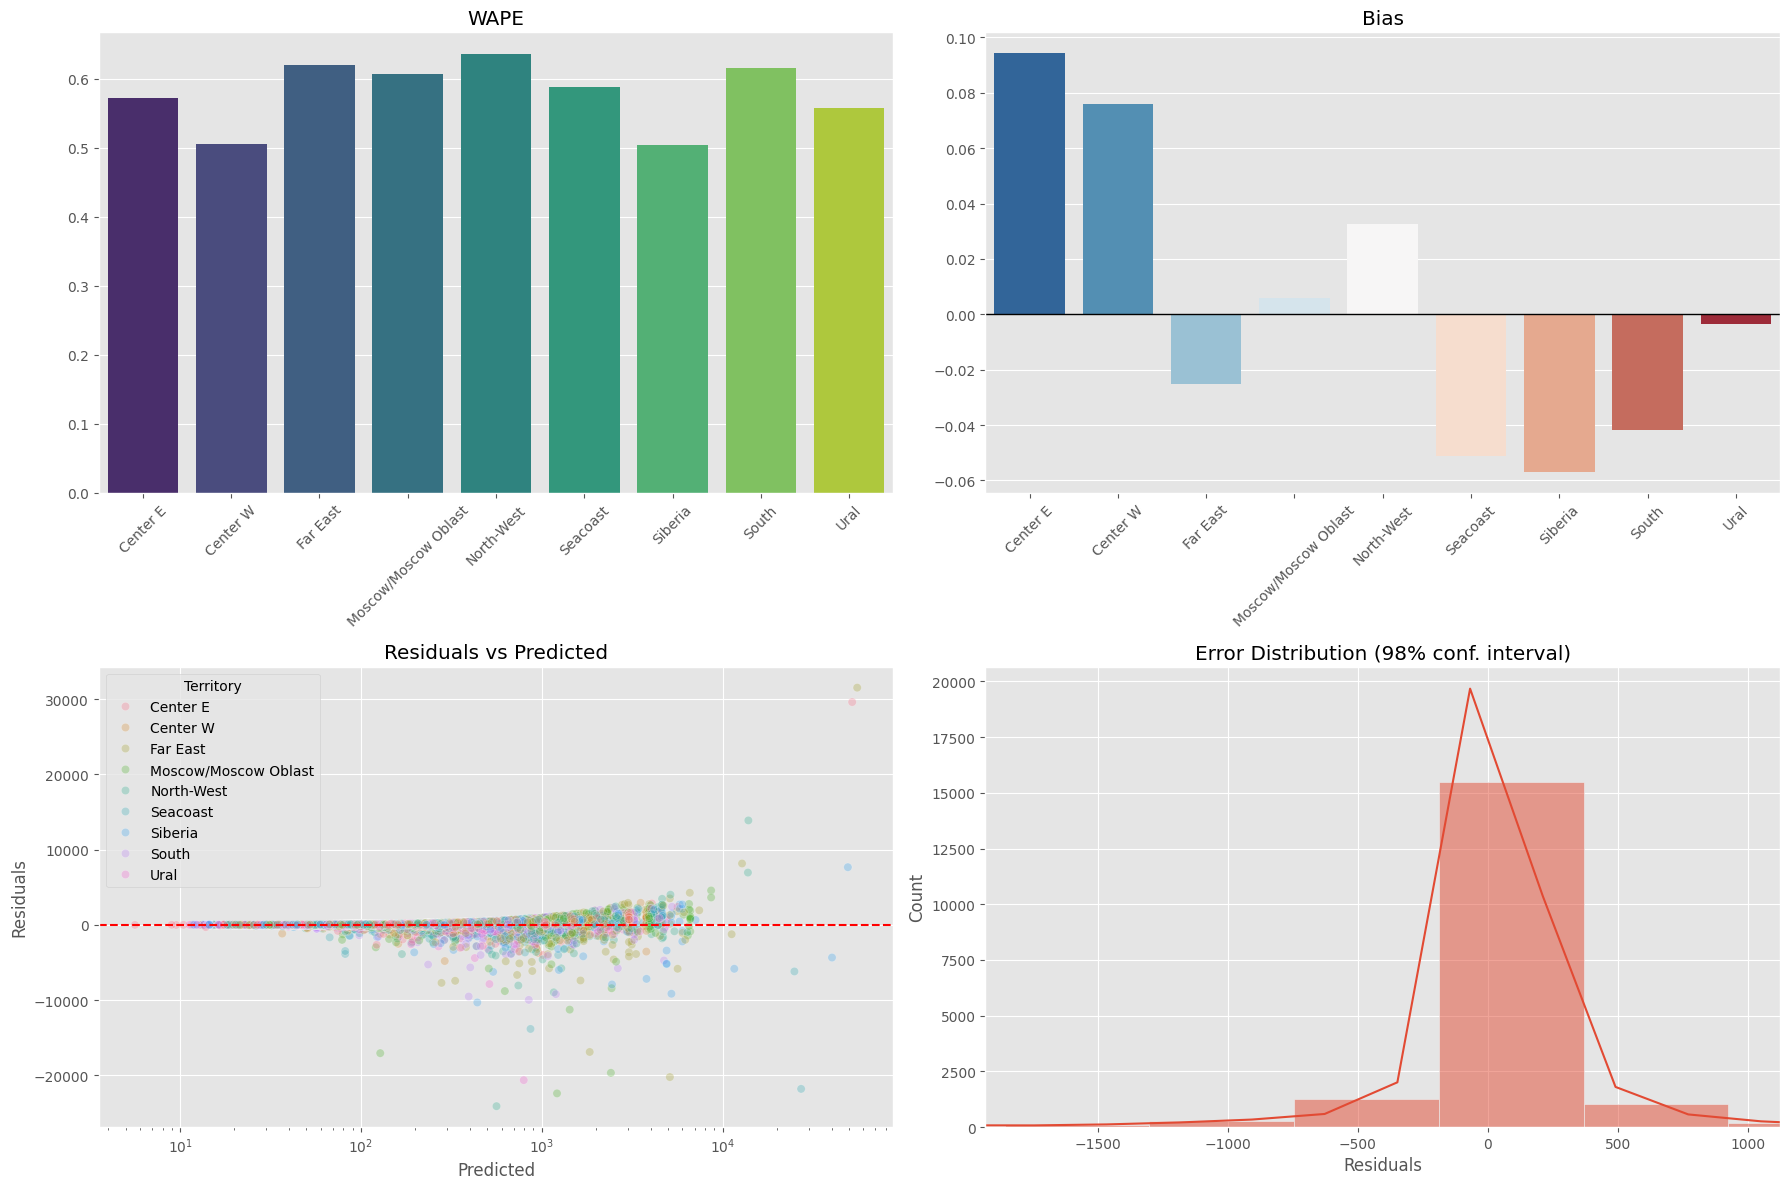

,Territory,MAE,WAPE,Bias,R2,Samples
0,Center E,155.103263,0.571563,0.094267,-0.138837,2557.0
1,Center W,151.076865,0.504954,0.075908,0.653013,1687.0
2,Far East,371.921044,0.619955,-0.025191,0.220231,1782.0
3,Moscow/Moscow Oblast,285.109439,0.606593,0.005837,0.322680,1789.0
4,North-West,266.107839,0.635601,0.032617,0.213259,1867.0
5,Seacoast,181.218875,0.588500,-0.051201,0.754780,2287.0
6,Siberia,204.239620,0.504698,-0.056870,0.840723,2401.0
7,South,174.435131,0.615132,-0.041706,0.384068,2744.0
8,Ural,188.515523,0.556996,-0.003462,0.328845,1565.0


In [ ]:
get_test_metrics_adjusted_by_territory(y_test, y_test_pred, pt, X_train_w_residuals, X_test['Territory'])

**Conclusions**:
---

1. The macro-regional dependence of R² is indicative of pronounced spatial differentiation in the data; consequently, training macro-regional models separately (on an extended sample) appears promising.
2. Model quality is constrained by an insufficient feature description of the observations (most notably continuous micro-features); in its current configuration, the model is excessively dependent on the low-cardinality analytical feature 'Potential'.
3. The influence of upper outliers on prediction quality persists; therefore, tail observations should be accumulated at the macro-regional level for the subsequent training of hurdle models.